# Skeleton stats

Attach each SegCLR embedding to its nearest node in the new mesh-derived TEASAR skeleton, strictly within the same `root_id`, and compare CAVE and TEASAR edge-length distributions.

The edge analysis keeps **three distinct groups**: CAVE, merged TEASAR (`vertices` / `edges`), and unmerged TEASAR (`vertices_unmerged` / `edges_unmerged`). Edge lengths are computed from coordinates rather than trusting cached attributes. The attachment keeps the complete merged TEASAR graph; nodes without an embedding receive a zero vector plus an explicit `embedding_mask=False`, while collisions are mean-pooled and recorded in `embedding_count`.

In [34]:
from pathlib import Path
from concurrent.futures import FIRST_COMPLETED, ThreadPoolExecutor, wait
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.spatial import cKDTree
from torch_geometric.data import Data

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "gnn").is_dir())
if not (ROOT / 'data').is_dir(): ROOT = ROOT.parent
GRAPH_DIR = ROOT / 'data' / 'graph_cache'
CAVE_DIR = ROOT / 'data' / 'skeleton_cache'
TEASAR_DIR = Path('/orcd/scratch/orcd/013/jcbliao/skeletons/segclr/skeletons')
OUTPUT_DIR = ROOT / 'data' / 'teasar_graph_cache'
MANIFEST = ROOT / 'data' / 'manifest.json'

MAX_CELLS = None      # entire common-root population
LOAD_WORKERS = 4      # bounded parallelism; also bounds peak per-cell RAM
CHUNK_EDGES = 2_000_000 # bounded memmap reads during summaries and plotting
EDGE_CACHE = Path('/orcd/scratch/orcd/013/jcbliao/skeletons/segclr/edge_length_cache')
REBUILD_EDGE_CACHE = False
PLOT_PERCENTILES = (0.5, 99.5) # trim pooled tails in each panel for readable bins
GMM_COMPONENTS = 2
SAVE_ATTACHED_GRAPHS = False # set True after inspecting alignment diagnostics
RNG_SEED = 0

manifest_ids = set(map(int, json.loads(MANIFEST.read_text())['cells']))
graph_ids = {int(p.stem) for p in GRAPH_DIR.glob('*.pt')}
cave_ids = {int(p.stem) for p in CAVE_DIR.glob('*.pkl')}
teasar_ids = {int(p.stem) for p in TEASAR_DIR.glob('*.npz')}
common_ids = sorted(manifest_ids & graph_ids & cave_ids & teasar_ids)
ROOT_IDS = common_ids if MAX_CELLS is None else common_ids[:MAX_CELLS]
print(f'{len(common_ids):,} roots have all inputs; processing {len(ROOT_IDS):,}')


2,335 roots have all inputs; processing 2,335


### Streaming GMM implementation

The left model is Gaussian in log10 edge length; the right is Gaussian in linear nanometers. Both use every merged-TEASAR edge inside the robust plotting interval. Labels mark every fitted component mean.

In [35]:
def run_gmm_section():
    merged_bounds = streaming_quantiles([merged_lengths], PLOT_PERCENTILES, log_bins=True)
    gmm_log = fit_streaming_gmm(merged_lengths, merged_bounds, log_space=True, n_components=GMM_COMPONENTS)
    gmm_linear = fit_streaming_gmm(merged_lengths, merged_bounds, log_space=False, n_components=GMM_COMPONENTS)
    display(pd.DataFrame({
        'component': np.arange(1, GMM_COMPONENTS + 1),
        'log_fit_weight': gmm_log['weights'], 'log_fit_mu_log10_nm': gmm_log['means'],
        'log_fit_center_nm': 10**gmm_log['means'], 'linear_fit_weight': gmm_linear['weights'],
        'linear_fit_mean_nm': gmm_linear['means'],
    }).round(3))
    print(f"EM iterations — log: {gmm_log['iterations']}, linear: {gmm_linear['iterations']}")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    plot_gmm_panel(axes[0], merged_lengths, merged_bounds, gmm_log, log_space=True)
    plot_gmm_panel(axes[1], merged_lengths, merged_bounds, gmm_linear, log_space=False)
    axes[0].set_title(f'{GMM_COMPONENTS}-component GMM in log10 space')
    axes[1].set_title(f'{GMM_COMPONENTS}-component GMM in linear space')
    fig.suptitle('Merged TEASAR edge-length mixture fits')
    fig.tight_layout()


## Gaussian-mixture helpers

Fit separate `GMM_COMPONENTS`-component Gaussian mixtures to the merged TEASAR distribution in log10-length space and linear nanometer space. EM streams over every edge within the same robust display bounds used above; it does not materialize the population in RAM. In the log panel, $\mu$ is a mean in log10 space and the labeled nanometer location is $10^\mu$; in the linear panel, $\mu$ is directly in nanometers. Component curves include their fitted mixture weights, and the black curve is their sum.

In [36]:
from scipy.special import logsumexp
from scipy.stats import norm

def fit_streaming_gmm(values, bounds, log_space=False, n_components=2, max_iter=100, tol=1e-6):
    initial = streaming_quantiles([values], np.linspace(15, 85, n_components), log_bins=log_space)
    means = np.log10(initial) if log_space else initial.astype(np.float64)
    transformed_bounds = np.log10(bounds) if log_space else np.asarray(bounds, dtype=np.float64)
    span = transformed_bounds[1] - transformed_bounds[0]
    sigmas = np.full(n_components, span / (2 * n_components))
    weights = np.full(n_components, 1 / n_components)
    previous_ll = -np.inf
    for iteration in range(max_iter):
        nk = np.zeros(n_components); sx = np.zeros(n_components); sx2 = np.zeros(n_components)
        log_likelihood = 0.0
        for chunk in chunks(values):
            x = chunk[(chunk > 0) & (chunk >= bounds[0]) & (chunk <= bounds[1])].astype(np.float64)
            if log_space: x = np.log10(x)
            log_joint = (np.log(weights)[None, :] - np.log(sigmas)[None, :]
                         - 0.5 * ((x[:, None] - means[None, :]) / sigmas[None, :])**2
                         - 0.5 * np.log(2 * np.pi))
            log_norm = logsumexp(log_joint, axis=1)
            responsibility = np.exp(log_joint - log_norm[:, None])
            nk += responsibility.sum(axis=0)
            sx += responsibility.T @ x
            sx2 += responsibility.T @ (x * x)
            log_likelihood += log_norm.sum()
        weights = nk / nk.sum()
        means = sx / nk
        variances = np.maximum(sx2 / nk - means**2, (span * 1e-6)**2)
        sigmas = np.sqrt(variances)
        if np.isfinite(previous_ll) and abs(log_likelihood - previous_ll) <= tol * (1 + abs(previous_ll)):
            break
        previous_ll = log_likelihood
    order = np.argsort(means)
    return {'weights': weights[order], 'means': means[order], 'sigmas': sigmas[order],
            'iterations': iteration + 1, 'log_likelihood': log_likelihood}



In [37]:
def plot_gmm_panel(ax, values, bounds, model, log_space):
    x_bins = np.geomspace(*bounds, 70) if log_space else np.linspace(*bounds, 70)
    observed = streaming_pmf(values, x_bins)
    ax.stairs(observed, x_bins, color='#228833', linewidth=2, label='merged TEASAR PMF')
    model_bins = np.log10(x_bins) if log_space else x_bins
    colors = plt.cm.tab10(np.arange(len(model['weights'])))
    parameters = list(zip(model['weights'], model['means'], model['sigmas'], colors))
    component_mass = [w * np.diff(norm.cdf(model_bins, loc=m, scale=s)) for w, m, s, _ in parameters]
    normalizer = np.sum(component_mass)
    component_mass = [mass / normalizer for mass in component_mass]
    centers = np.sqrt(x_bins[:-1] * x_bins[1:]) if log_space else (x_bins[:-1] + x_bins[1:]) / 2
    for i, ((weight, mean, sigma, color), mass) in enumerate(zip(parameters, component_mass), 1):
        center_nm = 10**mean if log_space else mean
        ax.plot(centers, mass, color=color, linestyle=':', linewidth=1.6, label=f'component {i} (w={weight:.2f})')
        ax.axvline(center_nm, color=color, linestyle='--', linewidth=1.4)
        ax.annotate(f'μ{i}={center_nm:,.0f} nm', xy=(center_nm, 0.96 - .10*(i-1)),
                    xycoords=('data', 'axes fraction'), rotation=90, va='top', ha='right', color=color)
    total_mass = np.sum(component_mass, axis=0)
    ax.plot(centers, total_mass, color='black', linewidth=2, label='GMM total')
    if log_space: ax.set_xscale('log')
    ax.set(xlabel='edge length (nm)', ylabel='probability mass per bin')
    ax.grid(alpha=.2); ax.legend()



## Nearest-node attachment

`graph.pos` is the location associated with each SegCLR row and `graph.x` is its embedding. A fresh `cKDTree` is built per TEASAR skeleton, so a query can never cross cell boundaries. Three independent root-ID assertions guard the join. Multiple embeddings mapping to one node are averaged rather than overwritten.

In [38]:
def _root_scalar(value):
    if torch.is_tensor(value): value = value.detach().cpu().reshape(-1)[0].item()
    return int(value)

def attach_embeddings_to_teasar(root_id, graph_dir=GRAPH_DIR, teasar_dir=TEASAR_DIR):
    root_id = int(root_id)
    graph_path = graph_dir / f'{root_id}.pt'
    skeleton_path = teasar_dir / f'{root_id}.npz'
    graph = torch.load(graph_path, map_location='cpu', weights_only=False)
    if _root_scalar(graph.root_id) != root_id:
        raise ValueError(f'graph root mismatch: requested {root_id}, stored {graph.root_id}')

    with np.load(skeleton_path) as z:
        stored_root = int(np.asarray(z['root_id']).reshape(-1)[0])
        if stored_root != root_id:
            raise ValueError(f'TEASAR root mismatch: filename {root_id}, stored {stored_root}')
        vertices = np.asarray(z['vertices'], dtype=np.float64)
        edges = np.asarray(z['edges'], dtype=np.int64)
        radius = np.asarray(z['radius'], dtype=np.float32)

    embedding_xyz = graph.pos.detach().cpu().numpy().astype(np.float64, copy=False)
    embeddings = graph.x.detach().cpu().numpy().astype(np.float32, copy=False)
    if len(embedding_xyz) != len(embeddings):
        raise ValueError(f'{root_id}: {len(embedding_xyz)} positions != {len(embeddings)} embeddings')
    distance_nm, nearest = cKDTree(vertices).query(embedding_xyz, k=1)

    sums = np.zeros((len(vertices), embeddings.shape[1]), dtype=np.float64)
    counts = np.zeros(len(vertices), dtype=np.int64)
    np.add.at(sums, nearest, embeddings)
    np.add.at(counts, nearest, 1)
    x = np.zeros_like(sums, dtype=np.float32)
    covered = counts > 0
    x[covered] = (sums[covered] / counts[covered, None]).astype(np.float32)

    # PyG convention here is symmetric directed edges, matching graph_cache.
    edge_index = np.concatenate((edges.T, edges[:, ::-1].T), axis=1) if len(edges) else np.empty((2, 0), dtype=np.int64)
    lengths = np.linalg.norm(vertices[edges[:, 0]] - vertices[edges[:, 1]], axis=1).astype(np.float32) if len(edges) else np.empty(0, dtype=np.float32)
    out = Data(
        x=torch.from_numpy(x), pos=torch.from_numpy(vertices.astype(np.float32)),
        edge_index=torch.from_numpy(edge_index).long(),
        edge_attr=torch.from_numpy(np.concatenate((lengths, lengths))[:, None]),
        radius=torch.from_numpy(radius), embedding_mask=torch.from_numpy(covered),
        embedding_count=torch.from_numpy(counts),
    )
    out.root_id = root_id
    out.embedding_source_node = torch.from_numpy(np.asarray(nearest, dtype=np.int64))
    out.embedding_match_distance_nm = torch.from_numpy(np.asarray(distance_nm, dtype=np.float32))
    out.n_embedding_rows = int(len(embeddings))
    return out

example = attach_embeddings_to_teasar(ROOT_IDS[0])
example


Data(x=[6103, 64], edge_index=[2, 12204], edge_attr=[12204, 1], pos=[6103, 3], radius=[6103], embedding_mask=[6103], embedding_count=[6103], root_id=864691134800773453, embedding_source_node=[346], embedding_match_distance_nm=[346], n_embedding_rows=346)

In [39]:
alignment_rows = []
if SAVE_ATTACHED_GRAPHS: OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for root_id in ROOT_IDS:
    attached = attach_embeddings_to_teasar(root_id)
    d = attached.embedding_match_distance_nm.numpy()
    counts = attached.embedding_count.numpy()
    alignment_rows.append({
        'root_id': root_id, 'n_embedding_rows': attached.n_embedding_rows,
        'n_teasar_nodes': attached.num_nodes, 'n_nodes_with_embedding': int((counts > 0).sum()),
        'collision_fraction': float(np.mean(counts[counts > 0] > 1)),
        'median_distance_nm': float(np.median(d)), 'p95_distance_nm': float(np.percentile(d, 95)),
        'max_distance_nm': float(d.max()), 'fraction_within_500nm': float(np.mean(d <= 500)),
    })
    if SAVE_ATTACHED_GRAPHS: torch.save(attached, OUTPUT_DIR / f'{root_id}.pt')
alignment = pd.DataFrame(alignment_rows)
display(alignment.describe(percentiles=[.5, .9, .95, .99]).T)
display(alignment.sort_values('p95_distance_nm', ascending=False).head(10))
if SAVE_ATTACHED_GRAPHS: print(f'saved {len(alignment):,} graphs to {OUTPUT_DIR}')


,count,mean,std,min,50%,90%,95%,99%,max
root_id,2335.0,8.646911e+17,4.762929e+08,8.646911e+17,8.646911e+17,8.646911e+17,8.646911e+17,8.646911e+17,8.646911e+17
n_embedding_rows,2335.0,5.195209e+03,3.231502e+03,1.780000e+02,4.567000e+03,8.615600e+03,1.200830e+04,1.769740e+04,2.543400e+04
n_teasar_nodes,2335.0,6.527416e+04,4.047655e+04,2.903000e+03,5.733600e+04,1.123932e+05,1.466820e+05,2.066960e+05,3.127980e+05
n_nodes_with_embedding,2335.0,5.107615e+03,3.150920e+03,1.720000e+02,4.513000e+03,8.493800e+03,1.172080e+04,1.716698e+04,2.473300e+04
collision_fraction,2335.0,1.632051e-02,1.794835e-02,0.000000e+00,1.142264e-02,2.577914e-02,3.264440e-02,1.145560e-01,1.309524e-01
median_distance_nm,2335.0,7.846715e+01,7.014118e+01,4.860530e+01,6.435628e+01,8.039983e+01,9.190727e+01,5.053743e+02,7.653636e+02
p95_distance_nm,2335.0,3.399017e+02,5.155252e+02,1.262175e+02,2.327536e+02,3.060492e+02,7.173823e+02,2.566597e+03,9.925553e+03
max_distance_nm,2335.0,4.515873e+03,3.415492e+03,7.287592e+02,4.272747e+03,5.742262e+03,6.099346e+03,1.663527e+04,1.076098e+05
fraction_within_500nm,2335.0,9.644426e-01,8.293785e-02,4.352557e-01,9.810083e-01,9.889327e-01,9.912869e-01,9.936452e-01,9.959896e-01


,root_id,n_embedding_rows,n_teasar_nodes,n_nodes_with_embedding,collision_fraction,median_distance_nm,p95_distance_nm,max_distance_nm,fraction_within_500nm
2033,864691136380816597,6767,89771,6328,0.023546,59.652279,9925.552734,107609.757812,0.910743
55,864691134991032954,4375,53038,4076,0.022571,66.984749,5929.020508,40963.996094,0.896229
1616,864691135990793216,5848,68455,5432,0.033689,71.369667,5777.365234,34465.375000,0.910226
265,864691135279678881,3915,37072,3692,0.023835,78.378761,5382.914062,44318.355469,0.926181
1413,864691135875763086,2372,31257,2198,0.038217,65.833344,4869.648438,24457.929688,0.911889
1909,864691136238257935,1413,21760,1228,0.121336,563.683167,2730.177979,4188.770996,0.480538
445,864691135388514689,1869,26353,1624,0.125616,435.926544,2694.231201,5022.366211,0.516319
1530,864691135942024705,1838,26972,1596,0.130952,765.363647,2687.964600,4268.354004,0.435256
1115,864691135741308308,1820,28672,1585,0.121767,595.555786,2674.444824,4468.626953,0.475275
1563,864691135954701347,1565,24596,1394,0.099713,453.763214,2647.603516,5108.277344,0.515655


## Edge-length distributions

CAVE lengths come from the complete cached skeleton, not the embedding-covered `graph_cache` subgraph. Merged and unmerged TEASAR arrays are loaded separately, never substituted for one another. **Every edge from every common root is included; there is no sampling.** Loading uses `LOAD_WORKERS` concurrent cells and immediately appends their lengths to raw float32 files under `EDGE_CACHE`. The complete populations are then reopened with `np.memmap`, so they remain disk-backed rather than being concatenated in RAM. Delete that cache or set `REBUILD_EDGE_CACHE=True` after changing source data. Both histograms are separately normalized probability mass functions. For readable axes, each panel uses shared bounds from `PLOT_PERCENTILES` of its pooled population and renormalizes over the displayed range. The summary table remains untrimmed. The left panel compares all three groups on logarithmic bins; the right compares only merged and unmerged TEASAR edges on linear bins. Dashed lines mark the means of the displayed distributions.

In [40]:
def cave_edge_lengths(root_id):
    with open(CAVE_DIR / f'{int(root_id)}.pkl', 'rb') as f:
        skeleton = pickle.load(f)
    coords = np.asarray(skeleton.coords, dtype=np.float64)
    edges = np.asarray(skeleton.edges, dtype=np.int64)
    return np.linalg.norm(coords[edges[:, 0]] - coords[edges[:, 1]], axis=1)

def teasar_edge_lengths(root_id):
    with np.load(TEASAR_DIR / f'{int(root_id)}.npz') as z:
        merged_coords = np.asarray(z['vertices'], dtype=np.float64)
        merged_edges = np.asarray(z['edges'], dtype=np.int64)
        merged = np.linalg.norm(merged_coords[merged_edges[:, 0]] - merged_coords[merged_edges[:, 1]], axis=1)
        if 'vertices_unmerged' not in z.files or 'edges_unmerged' not in z.files:
            return merged, None
        unmerged_coords = np.asarray(z['vertices_unmerged'], dtype=np.float64)
        unmerged_edges = np.asarray(z['edges_unmerged'], dtype=np.int64)
        unmerged = np.linalg.norm(unmerged_coords[unmerged_edges[:, 0]] - unmerged_coords[unmerged_edges[:, 1]], axis=1)
    return merged, unmerged

def load_edge_populations(root_id):
    cave = cave_edge_lengths(root_id).astype(np.float32)
    merged, unmerged = teasar_edge_lengths(root_id)
    merged = merged.astype(np.float32)
    unmerged = None if unmerged is None else unmerged.astype(np.float32)
    row = {'root_id': int(root_id), 'cave_edges': len(cave), 'merged_edges': len(merged),
           'unmerged_edges': len(unmerged) if unmerged is not None else 0,
           'has_unmerged': unmerged is not None}
    return cave, merged, unmerged, row

EDGE_CACHE.mkdir(parents=True, exist_ok=True)
cache_paths = {name: EDGE_CACHE / f'{name}.float32' for name in ('cave', 'merged', 'unmerged')}
meta_path = EDGE_CACHE / 'metadata.json'
signature = {'root_ids': ROOT_IDS, 'dtype': 'float32'}
cache_valid = False
if meta_path.exists() and not REBUILD_EDGE_CACHE:
    metadata = json.loads(meta_path.read_text())
    cache_valid = metadata.get('signature') == signature and all(p.exists() for p in cache_paths.values())

if not cache_valid:
    inventory_rows = []
    handles = {name: path.open('wb') for name, path in cache_paths.items()}
    roots = iter(ROOT_IDS)
    with ThreadPoolExecutor(max_workers=LOAD_WORKERS) as pool:
        pending = {}
        for _ in range(min(LOAD_WORKERS, len(ROOT_IDS))):
            root_id = next(roots); pending[pool.submit(load_edge_populations, root_id)] = root_id
        while pending:
            done, _ = wait(pending, return_when=FIRST_COMPLETED)
            for future in done:
                pending.pop(future)
                cave, merged, unmerged, row = future.result()
                cave.tofile(handles['cave']); merged.tofile(handles['merged'])
                if unmerged is not None: unmerged.tofile(handles['unmerged'])
                inventory_rows.append(row)
                try:
                    root_id = next(roots)
                except StopIteration:
                    continue
                pending[pool.submit(load_edge_populations, root_id)] = root_id
    for handle in handles.values(): handle.close()
    metadata = {'signature': signature, 'inventory': inventory_rows}
    meta_path.write_text(json.dumps(metadata))

inventory = pd.DataFrame(metadata['inventory'])
cave_lengths = np.memmap(cache_paths['cave'], dtype=np.float32, mode='r')
merged_lengths = np.memmap(cache_paths['merged'], dtype=np.float32, mode='r')
unmerged_lengths = np.memmap(cache_paths['unmerged'], dtype=np.float32, mode='r')
print(f"CAVE: {len(cave_lengths):,} edges (entire population)")
print(f"TEASAR merged: {len(merged_lengths):,} edges (entire population)")
print(f"TEASAR unmerged: {len(unmerged_lengths):,} edges (entire population); available for {inventory.has_unmerged.mean():.1%} of cells")


CAVE: 12,128,479 edges (entire population)
TEASAR merged: 152,412,820 edges (entire population)
TEASAR unmerged: 255,527,321 edges (entire population); available for 100.0% of cells


,n_edges,mean_nm,std_nm,p1_nm,p5_nm,p25_nm,p50_nm,p75_nm,p95_nm,p99_nm
skeleton,,,,,,,,,,
CAVE,12128479,2005.5,1153.6,186.7,523.9,1325.7,1864.6,2446.6,3856.6,6133.5
TEASAR merged,152412820,174.2,262.4,81.6,91.7,109.1,130.7,212.1,362.3,502.6
TEASAR unmerged,255527321,101.2,159.2,31.2,63.8,87.8,99.7,112.5,135.4,162.4


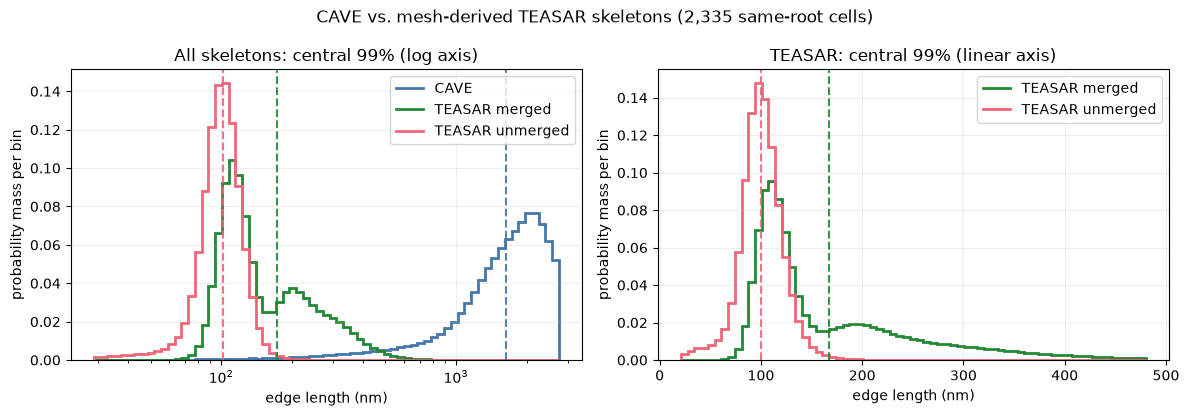

In [41]:
def chunks(values):
    for start in range(0, len(values), CHUNK_EDGES):
        yield np.asarray(values[start:start + CHUNK_EDGES])

def streaming_quantiles(arrays, percentiles, log_bins=False, resolution=20_000):
    lo = min(float(chunk[chunk > 0].min()) for a in arrays for chunk in chunks(a) if np.any(chunk > 0))
    hi = max(float(chunk.max()) for a in arrays for chunk in chunks(a))
    fine_bins = np.geomspace(lo, hi, resolution + 1) if log_bins else np.linspace(lo, hi, resolution + 1)
    counts = np.zeros(resolution, dtype=np.int64)
    for values in arrays:
        for chunk in chunks(values): counts += np.histogram(chunk[chunk > 0], bins=fine_bins)[0]
    cumulative = np.cumsum(counts)
    indices = np.searchsorted(cumulative, np.asarray(percentiles) / 100 * cumulative[-1], side='left')
    return fine_bins[np.minimum(indices, resolution - 1)]

def streaming_moments(values, bounds=None):
    n = 0; total = 0.0; total2 = 0.0
    for chunk in chunks(values):
        chunk = chunk[chunk > 0]
        if bounds is not None: chunk = chunk[(chunk >= bounds[0]) & (chunk <= bounds[1])]
        n += len(chunk); total += chunk.sum(dtype=np.float64); total2 += np.square(chunk, dtype=np.float64).sum()
    mean = total / n
    return n, mean, np.sqrt(max(0.0, total2 / n - mean**2))

def streaming_pmf(values, bins):
    counts = np.zeros(len(bins) - 1, dtype=np.int64)
    for chunk in chunks(values): counts += np.histogram(chunk, bins=bins)[0]
    return counts / counts.sum()

def summarize_lengths(name, values):
    ps = [1, 5, 25, 50, 75, 95, 99]
    q = streaming_quantiles([values], ps, log_bins=True)
    n, mean, std = streaming_moments(values)
    return {'skeleton': name, 'n_edges': n, 'mean_nm': mean, 'std_nm': std,
            **{f'p{p}_nm': v for p, v in zip(ps, q)}}

summary = pd.DataFrame([summarize_lengths('CAVE', cave_lengths),
                        summarize_lengths('TEASAR merged', merged_lengths),
                        summarize_lengths('TEASAR unmerged', unmerged_lengths)])
display(summary.set_index('skeleton').round(1))

groups = [(cave_lengths, 'CAVE', '#4477AA'),
          (merged_lengths, 'TEASAR merged', '#228833'),
          (unmerged_lengths, 'TEASAR unmerged', '#EE6677')]
log_lo, log_hi = streaming_quantiles([v for v, _, _ in groups], PLOT_PERCENTILES, log_bins=True)
bins = np.geomspace(log_lo, log_hi, 70)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for values, label, color in groups:
    # A proper discrete PMF over the shared bins: each edge contributes
    # mass 1/N, so each group's displayed bin heights sum to exactly one.
    probability_mass = streaming_pmf(values, bins)
    axes[0].stairs(probability_mass, bins, linewidth=2, label=label, color=color)
    _, mean, _ = streaming_moments(values, (log_lo, log_hi))
    axes[0].axvline(mean, color=color, linestyle='--', linewidth=1.5, alpha=.9)
teasar_groups = groups[1:]
linear_lo, linear_hi = streaming_quantiles([v for v, _, _ in teasar_groups], PLOT_PERCENTILES)
linear_bins = np.linspace(linear_lo, linear_hi, 70)
for values, label, color in teasar_groups:
    probability_mass = streaming_pmf(values, linear_bins)
    axes[1].stairs(probability_mass, linear_bins, linewidth=2, label=label, color=color)
    _, mean, _ = streaming_moments(values, (linear_lo, linear_hi))
    axes[1].axvline(mean, color=color, linestyle='--', linewidth=1.5, alpha=.9)
axes[0].set_xscale('log')
for ax in axes:
    ax.set_xlabel('edge length (nm)'); ax.set_ylabel('probability mass per bin'); ax.grid(alpha=.2); ax.legend()
kept = PLOT_PERCENTILES[1] - PLOT_PERCENTILES[0]
axes[0].set_title(f'All skeletons: central {kept:g}% (log axis)')
axes[1].set_title(f'TEASAR: central {kept:g}% (linear axis)')
fig.suptitle(f'CAVE vs. mesh-derived TEASAR skeletons ({len(ROOT_IDS):,} same-root cells)')
fig.tight_layout()


## Gaussian mixture fits: merged TEASAR only

Run the streaming log-space and linear-space fits and label every component mean.

,component,log_fit_weight,log_fit_mu_log10_nm,log_fit_center_nm,linear_fit_weight,linear_fit_mean_nm
0,1,0.528,2.046,111.164,0.529,112.762
1,2,0.472,2.344,220.778,0.471,235.603


EM iterations — log: 28, linear: 18


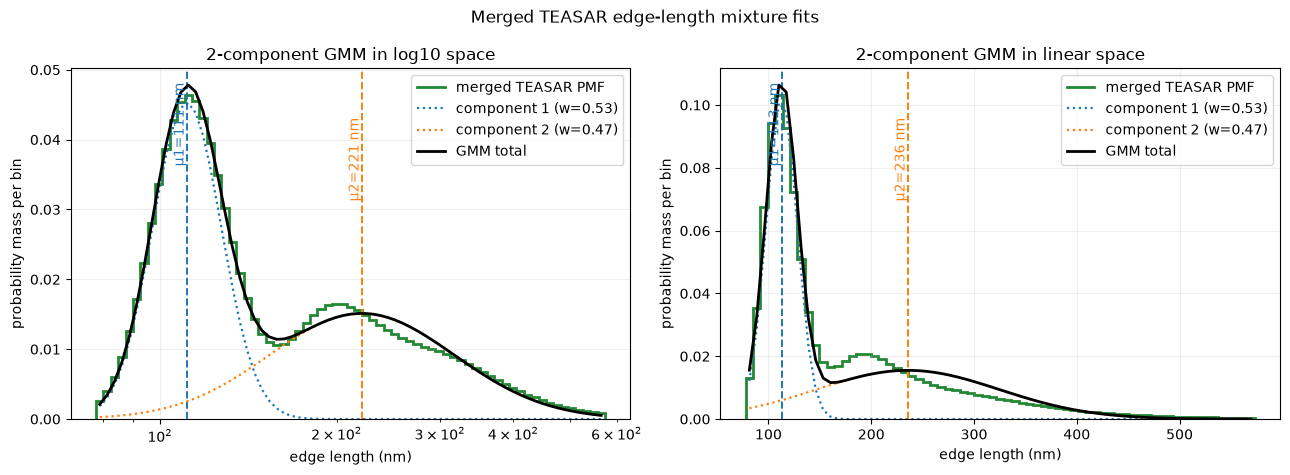

In [42]:
run_gmm_section()


## Reading the result

Inspect the nearest-distance table before enabling writes. Large residuals usually signal a coordinate-frame problem rather than a reason to accept a poor match. Compare TEASAR quantiles with CAVE to choose an upsampling target: a defensible first target is the CAVE median (or its full empirical spacing distribution), but upsampling should be decided after checking whether long TEASAR edges are localized artifacts and whether subdivision changes branch topology.